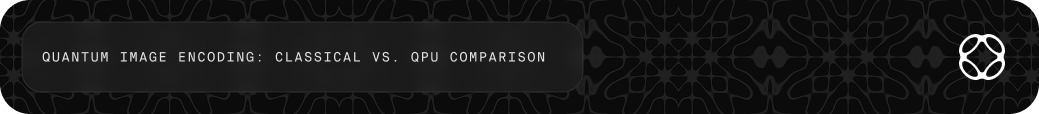

This notebook demonstrates **amplitude encoding** of grayscale images into quantum states, comparing two encoding strategies across multiple image resolutions:

**What are the methods?**

- **Qiskit StatePreparation (SP):** Full-vector state preparation — encodes the entire flattened image as a quantum amplitude vector. Exact but scales exponentially in qubit count.
- **Haiqu Block Vector Loading (BVL):** Tiled encoding — divides the image into spatial blocks, reducing per-circuit qubit count at the cost of approximate encoding fidelity.

The Haiqu Block Vector Loading method scales to significantly larger image sizes compared to standard state preparation.

In particular, images of size $256 \times 256$ are already impractical for state preparation due to the exponential scaling of circuit depth and gate count.

In contrast, the block-based vector loading approach remains tractable because it decomposes global state preparation into smaller local blocks. Moreover, the Haiqu state preparation within each block exhibits approximately power-law scaling, leading to substantially improved effective performance in practice, especially in the presence of quantum noise and hardware constraints.

This improved scalability comes with reconstruction accuracy:
- For $64 \times 64$ images, the Haiqu block vector loading yields approximately a **2x improvement** in fidelity compared to exact state preparation.
- Cost is fixed across all resolutions, thus for $128 \times 128$ images, the cost improvement reaches **89%**.
- As resolution grows, Haiqu BVL quality stays **above 90% for all tested resolutions**, while Qiskit State Preparation drops to 20% already halfway through.

> Note: QPU experiments were conducted in March, 2026. Your mileage may vary.

**What is the Workflow?**

- **Image preprocessing:** load, crop, and normalize a grayscale image.
- **Circuit construction:** build SP and BVL circuits for each (resolution, tile) configuration.
- **Cost estimation:** transpile circuits and collect 2Q-depth, gate counts, and QPU cost via dry run.
- **Execution:** run circuits on `ibm_boston` (QPU) and `aer_simulator` with MPS (classical).
- **Reconstruction:** convert measurement bitstring distributions back to pixel-space images.
- **Analysis:** compare reconstruction quality via state-vector fidelity $F = |\langle \psi_\text{ideal} | \psi_\text{recon} \rangle|^2$.

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

## Initialize the notebook

Import the necessary libraries, setup credentials, initialize the Haiqu SDK. Change the boolean variable if you want to run the full pipeline on a QPU.

In [1]:
# Import helper libraries
import numpy as np
import qiskit
from qiskit.circuit.library import StatePreparation
import json
import matplotlib.pyplot as plt
import os

# Standard setup: Connect to the Haiqu backend. Replace with your access key and URL if running outside the Haiqu Lab environment.
from haiqu.sdk import haiqu

from utils import *

haiqu.login()
haiqu.init("Quantum Image Encoding Demo")

'Set current experiment to: Quantum Image Encoding Demo'

In [2]:
run_on_QPU = False # Set to True only when ready to submit to real QPU (incurs cost)

## Image Loading & Preprocessing

Load the input image, convert to grayscale, and crop to a square aspect ratio. Pixel values are normalised to $[0, 1]$. The resulting `cropped_img` PIL Image is used as the source for all resolution-specific resizes later in the notebook.

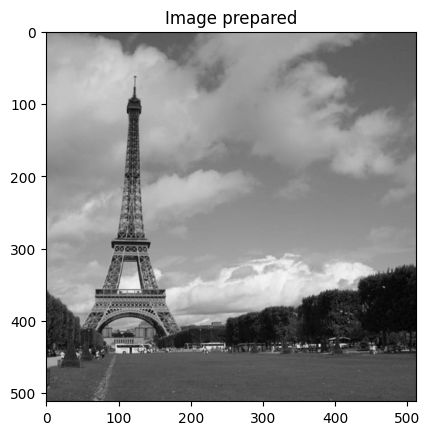

In [3]:
cropped_img = get_image()
resized_image = get_resized_image(cropped_img,target_size=(512, 512))

plt.imshow(resized_image, cmap='gray')
plt.title(f"Image prepared")
plt.show()

## Circuit Cost Estimation

This section configures the target QPU device and defines helpers for transpilation and cost estimation.

> **Credentials:** Replace `"IBM_QUANTUM_TOKEN"` and `"IBM_QUANTUM_INSTANCE"` with your actual IBM Quantum credentials, or inject them via environment variables before running.

In [4]:
if run_on_QPU:
    device_id = "ibm_boston"

    options = {
        "ibm_quantum_token": "IBM_QUANTUM_TOKEN",
        "ibm_quantum_instance": "IBM_QUANTUM_INSTANCE",
    }

### Results Container

Initialise the results dictionary that accumulates per-resolution experiment records, including circuit analytics, dry-run cost estimates, and job IDs for later retrieval.

In [5]:
if run_on_QPU:
    from datetime import datetime

    results = {
        "device": device_id,
        "date": datetime.now().isoformat(),
        "experiments": []
    }

## Transpilation & Cost Sweep

Define the (resolution, tile) configurations to benchmark. The tile grid determines how the image is partitioned for Block Vector Loading — finer tiles reduce per-block qubit count but increase the total number of qubits.

The cell below prints the total qubit count required for each configuration.

In [6]:

resolutions=[(16,16),(32,32),(64,64), (128,128), (192,192),(256,256)]
tiles=[(2,2),(4,4),(4,4), (2,4),(3,3),(2,4)]

for x,y in zip(resolutions,tiles):
    print(f"Number of qubits needed for the {x} resolution: {int(get_num_qubits(x,y))}")

Number of qubits needed for the (16, 16) resolution: 24
Number of qubits needed for the (32, 32) resolution: 96
Number of qubits needed for the (64, 64) resolution: 128
Number of qubits needed for the (128, 128) resolution: 88
Number of qubits needed for the (192, 192) resolution: 108
Number of qubits needed for the (256, 256) resolution: 104


### Utility functions

`get_best_transpiled_log` transpiles a circuit `n_seeds` times with `optimization_level=3` and returns the trial with the lowest two-qubit gate depth — a proxy for expected noise on real hardware.

In [7]:
def get_best_transpiled_log(
    circuit,
    device,
    haiqu,
    n_seeds: int = 20,
    optimization_level: int = 3,
):
    """
    Transpile `circuit` multiple times with different seeds and
    return the log corresponding to the minimal 2q depth.

    Objective:
        min_{s in [0, n_seeds)} depth_2q(T_s(circuit))
    """

    best_log = None
    best_circuit = None
    best_depth_2q = float("inf")

    for seed in range(n_seeds):
        transpiled = haiqu.transpile(
            circuit,
            device=haiqu.get_device(device),
            seed_transpiler=seed,
            optimization_level=optimization_level,
        )

        log = haiqu.log(transpiled)
        depth_2q = log.analytics.depth_2q

        if depth_2q < best_depth_2q:
            best_depth_2q = depth_2q
            best_log = log
            best_circuit = transpiled
            best_id = log.id
    return best_log, best_circuit, best_id


def run_circuit(circuit, haiqu, shots=30000):
    circuit = haiqu.transpile(circuit, device=haiqu.get_device("aer_simulator"))
    job_compressed = haiqu.run(
        circuit,
        shots=shots,
        device_id="aer_simulator",
        options={
            "method": "matrix_product_state",
            "matrix_product_state_max_bond_dimension": 80,
        },
    )
    saved_job_id = job_compressed.id

    res_dict = job_compressed.result()[0]
    return res_dict, saved_job_id


###

**Main Experiment Loop for each (resolution, tile) pair**

- Resize the image to the target resolution.
- Build the **Qiskit SP** circuit (skipped if the circuit would require more than 15 qubits).
- Build the **Haiqu BVL** circuit.
- Transpile both circuits using the best-seed strategy and record analytics (2Q depth, gate counts).
- Execute a dry run to obtain QPU cost estimates.
- Store all metadata in `results` for reproducibility.

### Qiskit State Preparation

In [8]:

if run_on_QPU:

    for target_size, tile in zip(resolutions, tiles):
        print("Running: target_size",target_size, "tile",tile)
        experiment_record = {
            "resolution": target_size,
            "tile": tile,
            "circuits": {}
        }

        resized_image = get_resized_image(cropped_img, target_size=target_size)

        # Qiskit SP
        # The largest statevector we can encode using the current method is 2^15, which corresponds to a 128 x 128 image.
        if np.log2(len(pad_to_power_of_two(resized_image.ravel())))<=15:
            qiskit_sp = StatePreparation(pad_to_power_of_two(resized_image.ravel()), normalize=True)
            circuit_qiskit = qiskit.QuantumCircuit(qiskit_sp.num_qubits, name="Qiskit")
            circuit_qiskit.compose(qiskit_sp, inplace=True)
            circuit_qiskit.measure_all()
        
            log_qiskit, transpiled_qiskit, qiskit_circuit_id = get_best_transpiled_log(
                circuit_qiskit,
                device_id,
                haiqu,
                n_seeds=5,
            )
        
            dry_job = haiqu.run(
                circuit_qiskit,
                device_id=device_id,
                shots=30000,
                options=options,
                dry_run=True,
            )
        
            experiment_record["circuits"]["qiskit_sp"] = {
                "num_qubits": circuit_qiskit.num_qubits,
                "analytics": serialize_analytics(dict(log_qiskit.analytics)),
                "dry_run_cost": serialize_cost(dry_job),
                "fidelity": 1.0,  # exact state preparation
                "id":qiskit_circuit_id
            }
        



### Haiqu Block Vector Encoding

In [9]:

if run_on_QPU:

    for target_size, tile in zip(resolutions, tiles):
        print("Running: target_size",target_size, "tile",tile)
        experiment_record = {
            "resolution": target_size,
            "tile": tile,
            "circuits": {}
        }

        resized_image = get_resized_image(cropped_img, target_size=target_size)
        
        # Block Vector Loading
        job = haiqu.block_vector_loading(
            data=resized_image.tolist(),
            num_blocks=tile,
        )
        block_gate = job.result()
        fidelity_block = job.quality

        circuit_block = qiskit.QuantumCircuit(block_gate.num_qubits, name="BVL")
        circuit_block.compose(block_gate, inplace=True)
        circuit_block.measure_all()

        log_block, transpiled_block, block_circuit_id = get_best_transpiled_log(
            circuit_block,
            device_id,
            haiqu,
            n_seeds=5,

        )

        dry_job_block = haiqu.run(
            circuit_block,
            device_id=device_id,
            shots=30000,
            options=options,
            dry_run=True,
        )

        experiment_record["circuits"]["block_vector_loading"] = {
            "num_qubits": circuit_block.num_qubits,
            "analytics": serialize_analytics(dict(log_block.analytics)),
            "dry_run_cost": serialize_cost(dry_job_block),
            "fidelity": float(fidelity_block),
            "id":block_circuit_id

        }
        print("Estimated cost from dry run:", serialize_cost(dry_job_block)["converted"]["amount"], "USD")
        results["experiments"].append(experiment_record)

### Execution and Results

## Circuit Execution

Submit each circuit to both backends:

- **QPU** (`ibm_boston`) — real quantum hardware execution with 30 000 shots.
- **Classical simulator** (`aer_simulator`) — Matrix Product State (MPS) method with bond dimension 80, providing a noiseless reference.

Job IDs are stored in `results` so reconstruction can be re-run without re-executing jobs.

In [10]:
if run_on_QPU:
    for resolution_data in results["experiments"]:
        resolution = resolution_data["resolution"]
        tile = resolution_data["tile"]
        resolution_data["results"] = {"qpu": {}, "classical": {}}
        for circuit_type in resolution_data["circuits"]:
            circuit = haiqu.get_circuit(resolution_data["circuits"][circuit_type]["id"])

            # QPU execution
            job_qpu = haiqu.run(
                circuit,
                device_id=device_id,
                shots=30000,
                options=options,
            )
            resolution_data["results"]["qpu"][circuit_type] = job_qpu.id

            # Classical simulation with MPS
            circuit = haiqu.transpile(circuit, device=haiqu.get_device("aer_simulator"))
            job_classical = haiqu.run(
                circuit,
                shots=30000,
                device_id="aer_simulator",
                options={
                    "method": "matrix_product_state",
                    "matrix_product_state_max_bond_dimension": 80,
                },
            )
            resolution_data["results"]["classical"][circuit_type] = job_classical.id

    with open("prod_data_no_images.json", "w") as f:
        json.dump(results, f, indent=4, )

## Load Results & Reconstruct Images

Load the persisted experiment data from `prod_data_no_images.json`, retrieve each job by ID, and convert measurement bitstring distributions back to pixel-space images.

Two reconstruction paths are applied depending on the encoding method:
- **BVL:** Split bitstrings by block → probabilities → amplitudes → pixel values (using stored per-block normalisation coefficients).
- **Qiskit SP:** Reshape the full probability vector directly into the image grid.

In [11]:
with open("prod_data_no_images.json", "r") as f:
    results = json.load(f,)

# itterating over different resolutions to get results and images
for resolution_data in results['experiments']:
    resolution = resolution_data["resolution"]
    tile = resolution_data["tile"]
    resolution_data["images"] = {"qpu": {}, "classical": {}}
    # itterating over circuit types (qiskit_sp, block_vector_loading)
    for circuit_type in resolution_data["circuits"]:
        image_resize = get_resized_image(cropped_img, target_size=resolution)
        resolution_data["images"]["classical"][circuit_type] = {}
        # CPU results retrieval
        classical_job_id = resolution_data["results"]["classical"][circuit_type]
        job = haiqu.get_job(classical_job_id)
        classical_result = job.result()[0]
        # QPU results retrieval
        saved_job_id = resolution_data["results"]["qpu"][circuit_type]
        job = haiqu.get_job(saved_job_id)
        qpu_result = job.result()[0]

        if circuit_type == "block_vector_loading":
            # CPU run image restoration 
            image_reconstructed_block = image_from_block_results(classical_result, image_resize, tile)
            resolution_data["images"]["classical"][circuit_type] = image_reconstructed_block
            # QPU run image restoration
            image_reconstructed_block = image_from_block_results(qpu_result, image_resize, tile)
            resolution_data["images"]["qpu"][circuit_type] = image_reconstructed_block


        elif circuit_type == "qiskit_sp":
            # CPU run image restoration 
            image_reconstructed_qiskit = bitstringdict_to_prob(classical_result, resolution)
            resolution_data["images"]["classical"][circuit_type] = image_reconstructed_qiskit
            # QPU run image restoration
            image_reconstructed_qiskit = bitstringdict_to_prob(qpu_result, resolution)
            resolution_data["images"]["qpu"][circuit_type] = image_reconstructed_qiskit

## Visual Comparison

Side-by-side comparison of original vs. reconstructed images for each encoding method and backend. Pixel values outside $[0, 1]$ are highlighted in red.

In [12]:
os.makedirs("figures", exist_ok=True)

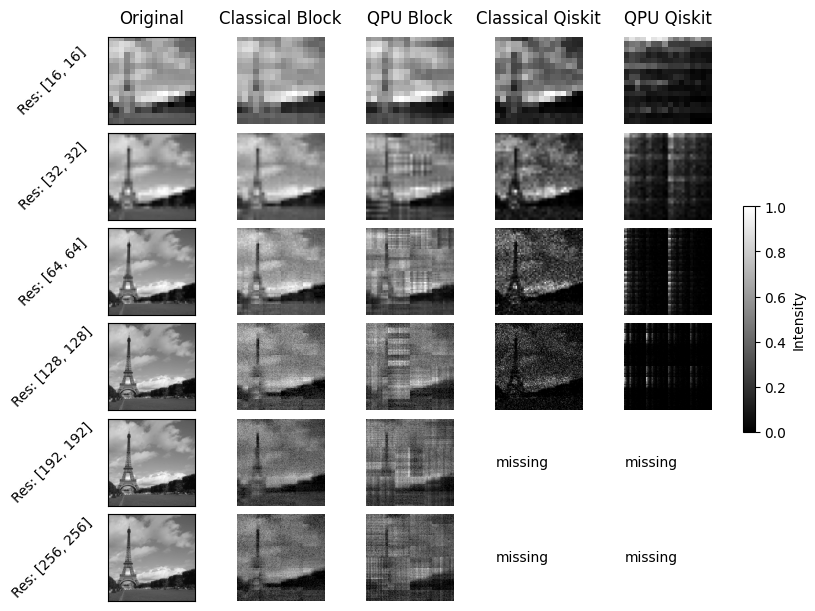

"Logged object to the experiment 'Quantum Image Encoding Demo'. You can see logged data on Dashboard: https://dashboard.haiqu.ai"

In [13]:
from utils import plot_image_encoding_grid

fig, axes = plot_image_encoding_grid(
    results=results,
    cropped_img=cropped_img,
    save_path="figures/clean_grid_6x5.png",
    dpi=300,
    show=True,
)

haiqu.log(
    fig,
    name='Resolutions grid',
    description='Resolutions for '
    'Haiqu BVL vs Qiskit circuits.'
)

## Resolution vs. Circuit Metrics

To evaluate how image resolution impacts circuit quality and execution overhead, we focus on two key metrics:

- **`Depth2q`**: the two-qubit gate depth, used as a proxy for circuit robustness. Lower values generally imply fewer opportunities for error accumulation on noisy hardware.
- **`Cost`**: the estimated monetary cost (USD) to execute the circuit on a QPU.

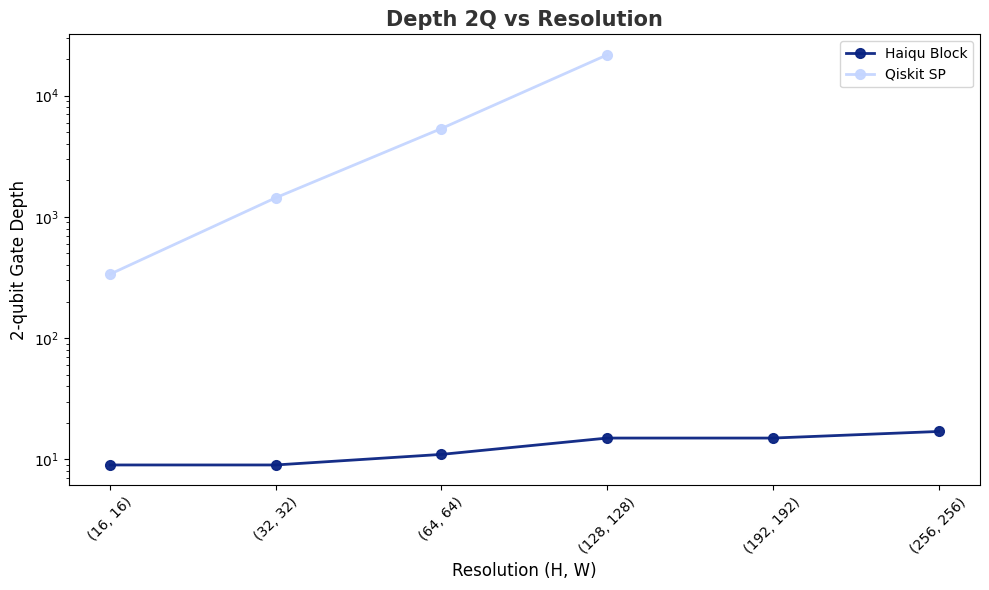

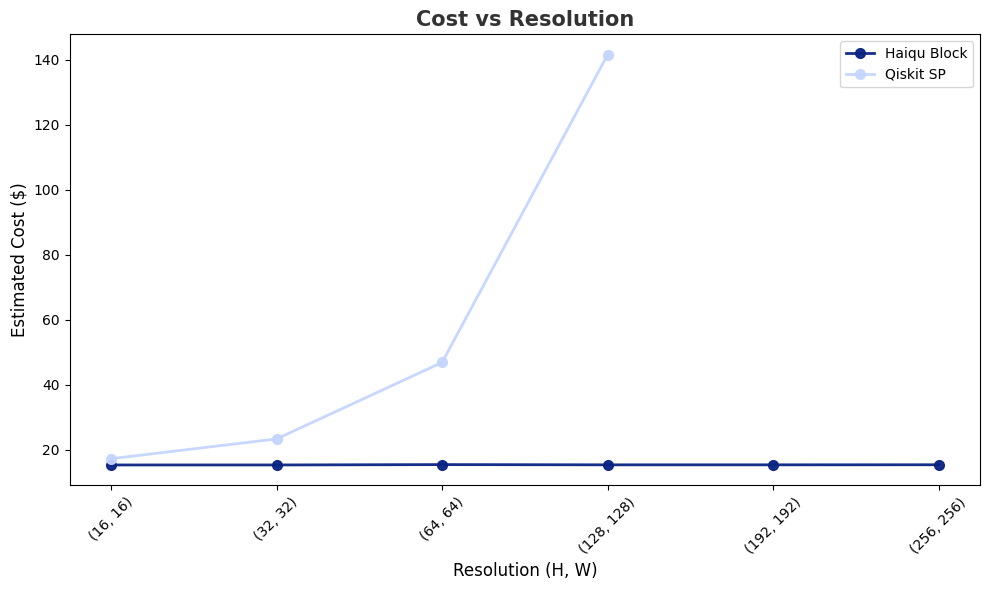

"Logged object to the experiment 'Quantum Image Encoding Demo'. You can see logged data on Dashboard: https://dashboard.haiqu.ai"

In [14]:
fig, ax, plot_data = plot_metrics_vs_resolution(results, 
                           metric="depth_2q",
                           save_path="figures/depth_2q_vs_resolution.png",
                           logscale=True)

haiqu.log(
    fig,
    name='Depth vs Resolution',
    description='2-qubit depths and resolutions for '
    'Haiqu BVL vs Qiskit circuits on IBM Boston.'
)

fig, ax, plot_data = plot_metrics_vs_resolution(results,
                           metric="cost", 
                           save_path="figures/cost_vs_resolution_cost.png",
                           logscale=False)

haiqu.log(
    fig,
    name='Cost vs Resolution',
    description='Cost and resolutions for '
    'Haiqu BVL vs Qiskit circuits on IBM Boston.'
)

## Encoding Quality Analysis

Quantify reconstruction quality using **state-vector fidelity**:

$$F = |\langle \psi_{\text{ideal}} \mid \psi_{\text{reconstructed}} \rangle|^2$$

where $|\psi\rangle$ is the normalised amplitude vector derived from the pixel image ($\psi_i = \sqrt{p_i}$, $\|\psi\| = 1$). A fidelity of $1.0$ indicates perfect reconstruction; lower values reflect hardware noise or approximation introduced by tiling.

Two views are shown:
- **QPU-only** — focuses on real hardware performance.
- **All backends** — includes classical MPS simulation for comparison.

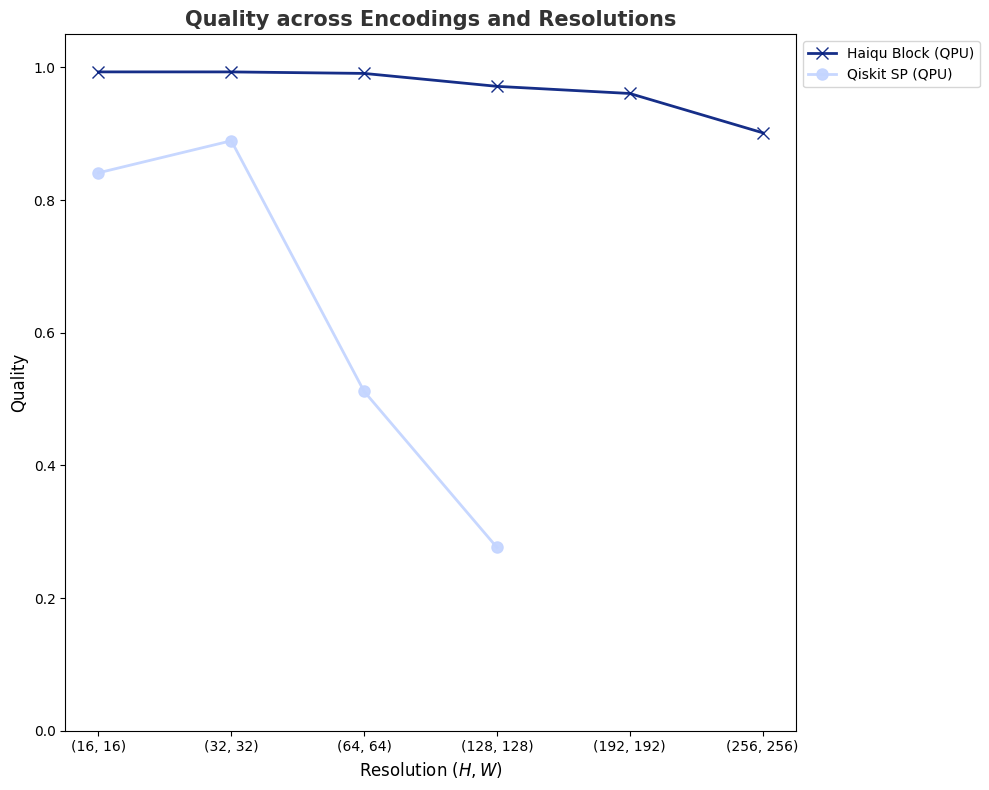

"Logged object to the experiment 'Quantum Image Encoding Demo'. You can see logged data on Dashboard: https://dashboard.haiqu.ai"

In [15]:
from utils import plot_fidelity_vs_resolution

fig, ax, plot_data = plot_fidelity_vs_resolution(
    results=results,
    cropped_img=cropped_img,
    save_path="figures/fidelity_vs_resolution_y_axis.png",
    dpi=300,
    show=True,
)

haiqu.log(
    fig,
    name='Quality vs Resolution',
    description='Quality (1 - |error|) and resolutions for '
    'Haiqu BVL vs Qiskit circuits on IBM Boston.'
)

"Logged object to the experiment 'Quantum Image Encoding Demo'. You can see logged data on Dashboard: https://dashboard.haiqu.ai"

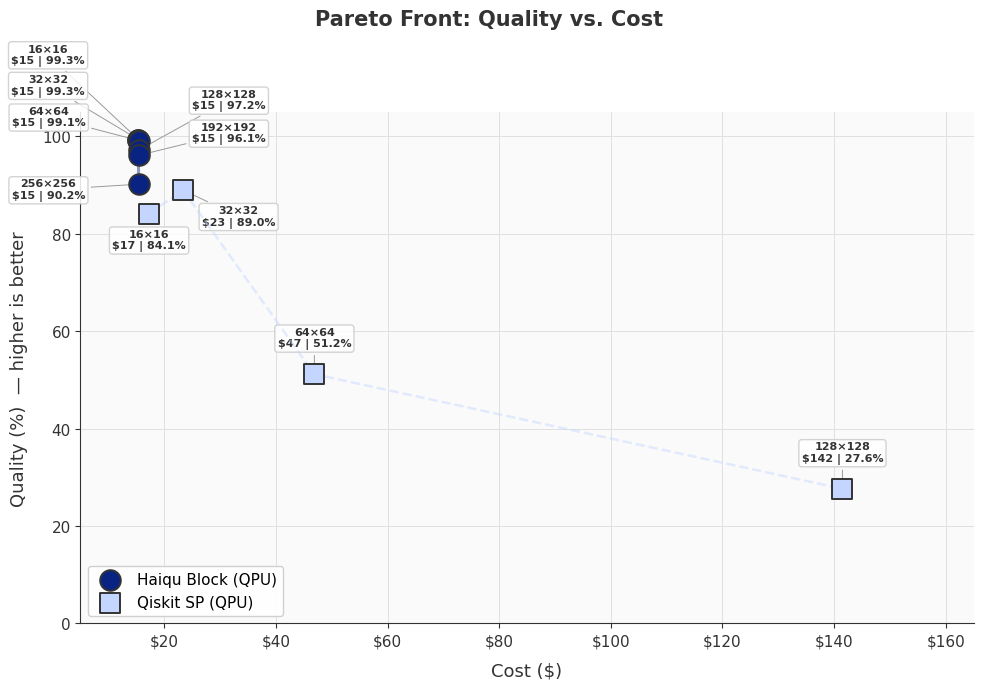

In [16]:
from utils import plot_pareto

fig = plot_pareto(results=results, cropped_img=cropped_img)

haiqu.log(
    fig,
    name='Quality vs Cost',
    description='Quality (1 - |error|) and cost for '
    'Haiqu BVL vs Qiskit circuits on IBM Boston.'
)

## Conclusions

- Haiqu achieves **polynomial** 2-qubit gate depth increase vs exponential for Qiskit.

- Haiqu maintains constant price across resolutions, resulting in as much as **89%** cost reduction for $128 \times 128$.

- Quality remains above **90%** for Haiqu BVL, while Qiskit SP drops to 20%.

## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

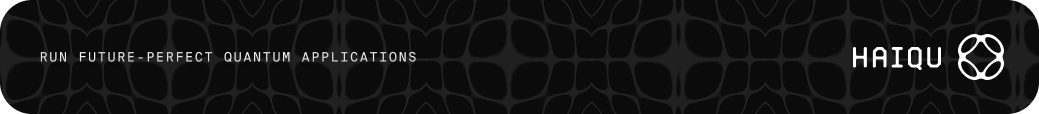